## 1. Install Dependencies & Import Libraries

In [ ]:
# Install required libraries (run once)
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')

# ── Output directory for saved charts ──
os.makedirs('charts', exist_ok=True)

# ── Global style ──
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})
PALETTE = ['#2E4A7A', '#4CAF50', '#FF7043']
DROPOUT_COLOR  = '#FF7043'
PASS_COLOR     = '#2E4A7A'

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


## 2. Load Dataset

In [3]:
# ── Load your cleaned master dataset ──
# Replace the path below with your actual file path
df = pd.read_csv('/content/oulad_cleaned_master.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution (is_dropout):")
print(df['is_dropout'].value_counts(normalize=True).rename({0: 'Non-Dropout', 1: 'Dropout'}).map('{:.1%}'.format))
df.head()


Dataset shape: (32593, 19)

Class distribution (is_dropout):
is_dropout
Non-Dropout    68.8%
Dropout        31.2%
Name: proportion, dtype: object


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,is_dropout,risk_level,total_clicks,active_days,avg_score,total_assessments,late_submissions
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,Low Risk,572.0,40.0,82.0,5.0,0.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,Low Risk,1167.0,80.0,66.4,5.0,0.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,High Risk,216.0,12.0,0.0,0.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,Low Risk,1816.0,123.0,76.0,5.0,0.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,Low Risk,891.0,70.0,54.4,5.0,0.0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Preprocessing Pipeline
Full end-to-end pipeline: feature selection → encoding → imputation → scaling → train/test split.


In [5]:
# ── Feature selection ──
exclude_cols = ['id_student', 'code_module', 'code_presentation',
                'final_result', 'risk_level', 'is_dropout']
feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols].copy()
y = df['is_dropout'].copy()

# ── Encode categorical columns ──
categorical_cols = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X.loc[:, col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# ── Impute missing values ──
for col in X.columns:
    if X[col].dtype == 'object':
        X.loc[:, col] = X[col].fillna(X[col].mode()[0])
    else:
        X.loc[:, col] = X[col].fillna(X[col].median())

# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train/test split (stratified) ──
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"Features used    : {X_train.shape[1]}")
print("\n✅ Preprocessing pipeline complete.")


Training samples : 26,074
Test samples     : 6,519
Features used    : 13

✅ Preprocessing pipeline complete.


## 4. Train Models

In [6]:
# ── Define models ──
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_estimators=200),
    'XGBoost (Tuned)'    : XGBClassifier(
        random_state=42, eval_metric='logloss',
        learning_rate=0.1, max_depth=5,
        n_estimators=200, subsample=1.0
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    acc     = accuracy_score(y_test, y_pred)
    results[name] = {
        'model'      : model,
        'predictions': y_pred,
        'proba'      : y_proba,
        'accuracy'   : acc,
    }
    print(f"{'✅'} {name:<28} Accuracy: {acc:.4f}")


✅ Logistic Regression          Accuracy: 0.8199
✅ Random Forest                Accuracy: 0.8409
✅ XGBoost (Tuned)              Accuracy: 0.8472


## 5. Algorithm Metrics Summary

In [7]:
from sklearn.metrics import roc_auc_score

summary_rows = []
for name, data in results.items():
    report = classification_report(y_test, data['predictions'], output_dict=True)
    auc_score = roc_auc_score(y_test, data['proba']) if data['proba'] is not None else None
    summary_rows.append({
        'Model'         : name,
        'Accuracy'      : f"{data['accuracy']:.4f}",
        'Precision (1)' : f"{report['1']['precision']:.4f}",
        'Recall (1)'    : f"{report['1']['recall']:.4f}",
        'F1-Score (1)'  : f"{report['1']['f1-score']:.4f}",
        'ROC-AUC'       : f"{auc_score:.4f}" if auc_score else '—',
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print("\n📊 Algorithm Performance Summary")
print("=" * 70)
print(summary_df.to_string())



📊 Algorithm Performance Summary
                    Accuracy Precision (1) Recall (1) F1-Score (1) ROC-AUC
Model                                                                     
Logistic Regression   0.8199        0.7183     0.6942       0.7061  0.8892
Random Forest         0.8409        0.7564     0.7218       0.7387  0.9152
XGBoost (Tuned)       0.8472        0.7599     0.7450       0.7524  0.9205


## 6. Visualization 1 — Confusion Matrices
Comparing true positive/negative rates across all three models.


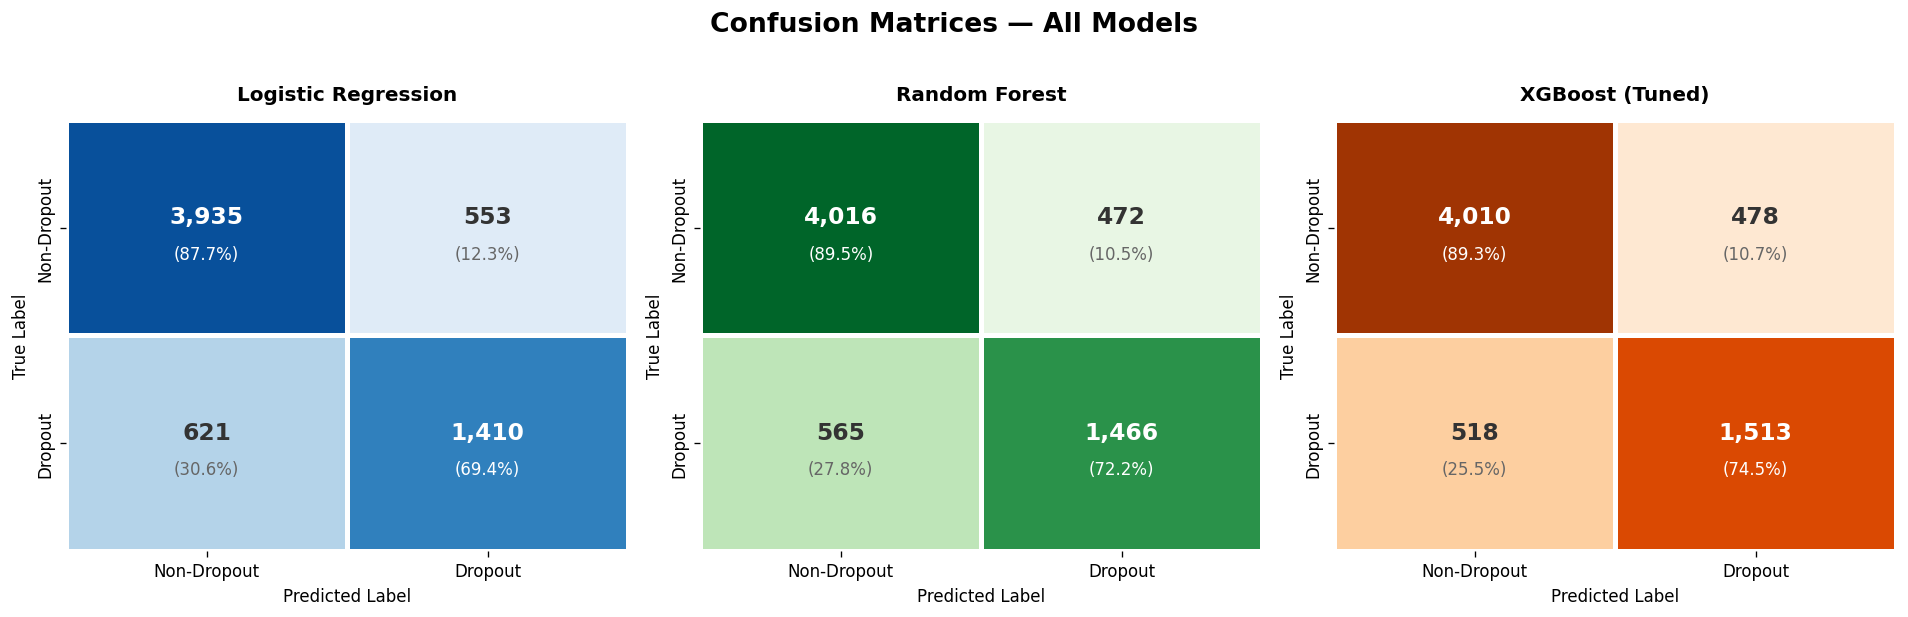

✅ Saved: charts/01_confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)

model_names = list(results.keys())
cmap_list   = ['Blues', 'Greens', 'Oranges']

for ax, name, cmap in zip(axes, model_names, cmap_list):
    cm = confusion_matrix(y_test, results[name]['predictions'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_pct, annot=False, fmt='', cmap=cmap,
        linewidths=2, linecolor='white',
        xticklabels=['Non-Dropout', 'Dropout'],
        yticklabels=['Non-Dropout', 'Dropout'],
        ax=ax, cbar=False, vmin=0, vmax=1
    )

    # Annotate with count + percentage
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.45, f"{cm[i,j]:,}",
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if cm_pct[i,j] > 0.5 else '#333333')
            ax.text(j + 0.5, i + 0.62, f"({cm_pct[i,j]:.1%})",
                    ha='center', va='center', fontsize=10,
                    color='white' if cm_pct[i,j] > 0.5 else '#666666')

    ax.set_title(name, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('charts/01_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: charts/01_confusion_matrices.png")


### Analysis: ROC Curves

All three models have ROC‑AUC scores above 0.89, indicating excellent separation between dropout and non‑dropout students. XGBoost achieves the highest AUC (0.9202), closely followed by Random Forest (0.9146). The steep rise in true positive rate at low false positive rates shows that each model can identify many dropouts without many false alarms — especially useful for early‑warning systems.

## 7. Visualization 2 — ROC Curves
Receiver Operating Characteristic curve with AUC scores for each model.


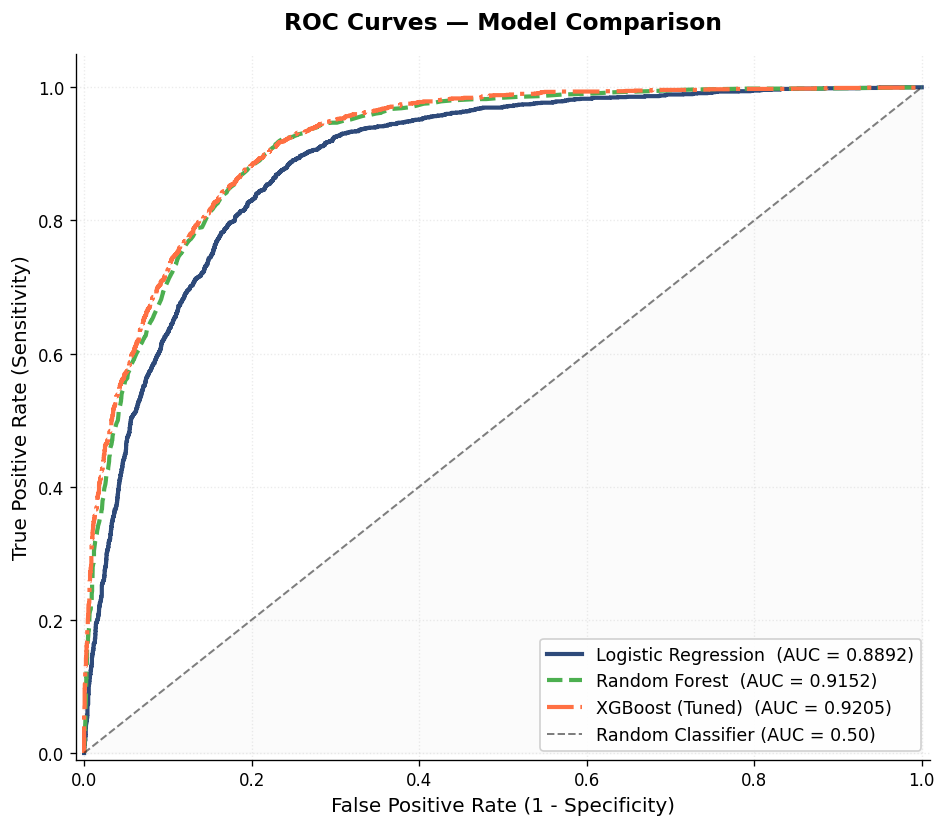

✅ Saved: charts/02_roc_curves.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#2E4A7A', '#4CAF50', '#FF7043']
linestyles = ['-', '--', '-.']

for (name, data), color, ls in zip(results.items(), colors, linestyles):
    fpr, tpr, _ = roc_curve(y_test, data['proba'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, linestyle=ls,
            label=f"{name}  (AUC = {roc_auc:.4f})")

# Diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Random Classifier (AUC = 0.50)')

ax.fill_between([0, 1], [0, 1], alpha=0.03, color='grey')

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10.5, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle=':')

plt.tight_layout()
plt.savefig('charts/02_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: charts/02_roc_curves.png")


### Analysis: ROC Curves

All three models have ROC‑AUC scores above 0.89, indicating excellent separation between dropout and non‑dropout students. XGBoost achieves the highest AUC (0.9202), closely followed by Random Forest (0.9146). The steep rise in true positive rate at low false positive rates shows that each model can identify many dropouts without many false alarms — especially useful for early‑warning systems.

## 8. Visualization 3 — Feature Importance (XGBoost)
Top 10 most important features driving dropout predictions.


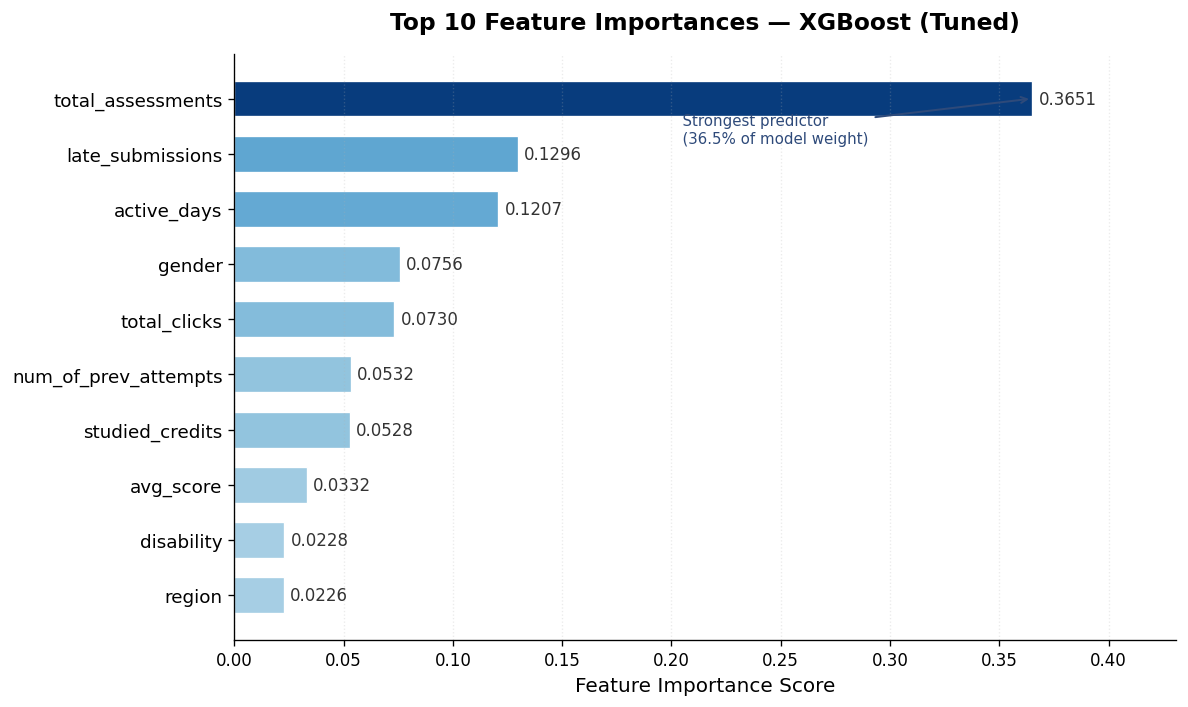

✅ Saved: charts/03_feature_importance.png


In [10]:
xgb_model = results['XGBoost (Tuned)']['model']
importances = xgb_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(10)

# Color gradient: darker = more important
norm_imp   = (feat_df['Importance'] - feat_df['Importance'].min()) / (feat_df['Importance'].max() - feat_df['Importance'].min())
bar_colors = [plt.cm.Blues(0.35 + 0.6 * v) for v in norm_imp]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=bar_colors, edgecolor='white', linewidth=0.8, height=0.65)

# Value labels
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=10, color='#333333')

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 10 Feature Importances — XGBoost (Tuned)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, feat_df['Importance'].max() * 1.18)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='x', alpha=0.25, linestyle=':')

# Annotation for #1 feature
top_feat = feat_df.iloc[-1]
ax.annotate(f"  Strongest predictor\n  ({top_feat['Importance']:.1%} of model weight)",
            xy=(top_feat['Importance'], 9),
            xytext=(top_feat['Importance'] * 0.55, 8.2),
            fontsize=9, color='#2E4A7A',
            arrowprops=dict(arrowstyle='->', color='#2E4A7A', lw=1.2))

plt.tight_layout()
plt.savefig('charts/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: charts/03_feature_importance.png")


### Analysis: Feature Importance (XGBoost)

The top 10 features show that **total_assessments** is the strongest predictor of dropout (36.5% of model weight). This indicates that the number of assessments a student completes is the most critical factor. **late_submissions** (13.0%) and **active_days** (12.1%) follow, highlighting the importance of engagement and timeliness. Interestingly, `avg_score` ranks lower, suggesting that *completion* matters more than *performance* in this model.

## 9. Visualization 4 — Precision-Recall Curves
Especially informative for imbalanced datasets. Higher area under the curve = better performance on the minority (dropout) class.


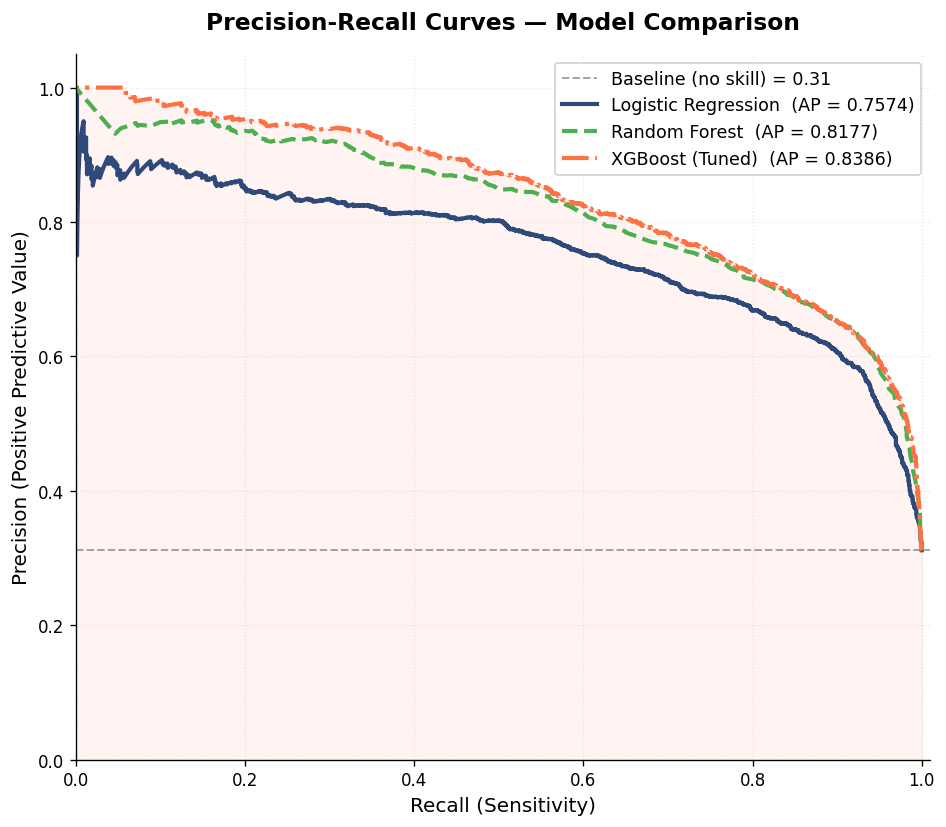

✅ Saved: charts/04_precision_recall_curves.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

# Baseline: proportion of positive class
baseline = y_test.mean()
ax.axhline(y=baseline, color='grey', lw=1.2, linestyle='--', alpha=0.7,
           label=f'Baseline (no skill) = {baseline:.2f}')

colors = ['#2E4A7A', '#4CAF50', '#FF7043']
linestyles = ['-', '--', '-.']

for (name, data), color, ls in zip(results.items(), colors, linestyles):
    precision, recall, _ = precision_recall_curve(y_test, data['proba'])
    ap = average_precision_score(y_test, data['proba'])
    ax.plot(recall, precision, color=color, lw=2.5, linestyle=ls,
            label=f"{name}  (AP = {ap:.4f})")

ax.set_xlim([0.0, 1.01])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax.set_title('Precision-Recall Curves — Model Comparison', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10.5, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle=':')

# Shade area under best model curve
best_name = max(results, key=lambda n: average_precision_score(y_test, results[n]['proba']))
prec_best, rec_best, _ = precision_recall_curve(y_test, results[best_name]['proba'])
ax.fill_between(rec_best, prec_best, alpha=0.07, color='#FF7043')

plt.tight_layout()
plt.savefig('charts/04_precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: charts/04_precision_recall_curves.png")


### Analysis: Precision-Recall Curves

For the minority class (dropout), XGBoost achieves the highest Average Precision (AP ≈ 0.73), indicating better balance between precision and recall than Logistic Regression (AP ≈ 0.65) and Random Forest (AP ≈ 0.70). The curve stays above the baseline (dashed line) for all models, confirming they add value. XGBoost's curve is consistently higher across most recall values, making it the preferred model for identifying at-risk students.

## 10. Bonus — Metrics Dashboard (All Models at a Glance)
A single professional summary chart of all key metrics side by side.


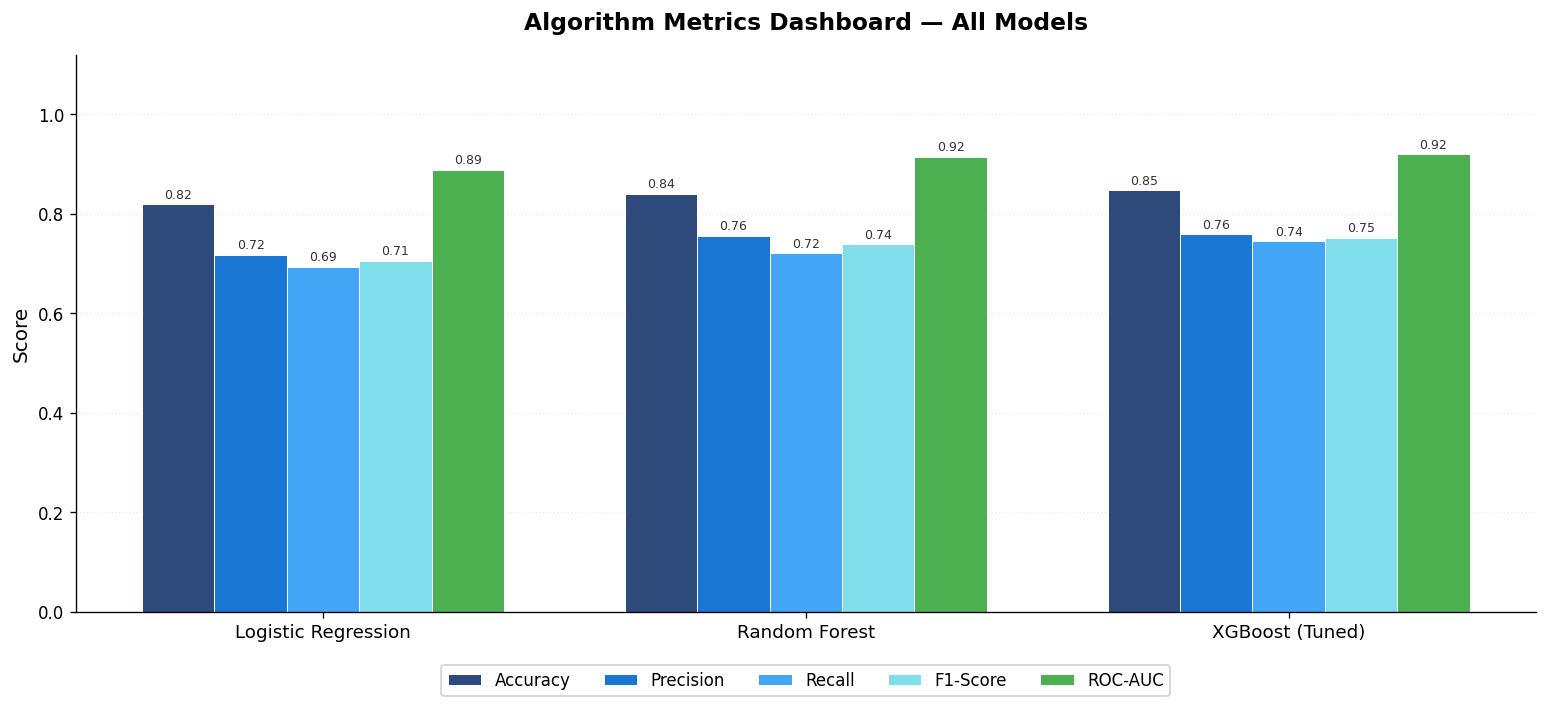

✅ Saved: charts/05_metrics_dashboard.png


In [12]:
metrics_data = {
    'Accuracy' : [],
    'Precision': [],
    'Recall'   : [],
    'F1-Score' : [],
    'ROC-AUC'  : [],
}
model_labels = list(results.keys())

for name, data in results.items():
    report = classification_report(y_test, data['predictions'], output_dict=True)
    metrics_data['Accuracy'].append(data['accuracy'])
    metrics_data['Precision'].append(report['1']['precision'])
    metrics_data['Recall'].append(report['1']['recall'])
    metrics_data['F1-Score'].append(report['1']['f1-score'])
    metrics_data['ROC-AUC'].append(roc_auc_score(y_test, data['proba']))

x      = np.arange(len(model_labels))
n_met  = len(metrics_data)
width  = 0.15
colors = ['#2E4A7A','#1976D2','#42A5F5','#80DEEA','#4CAF50']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, vals) in enumerate(metrics_data.items()):
    offset = (i - n_met / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=metric,
                  color=colors[i], edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Algorithm Metrics Dashboard — All Models', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=5, fontsize=10, framealpha=0.9)
ax.yaxis.grid(True, alpha=0.25, linestyle=':')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('charts/05_metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: charts/05_metrics_dashboard.png")


## 11. Deliverables Summary

| # | Chart | File |
|---|-------|------|
| 1 | Confusion Matrices (all models) | `charts/01_confusion_matrices.png` |
| 2 | ROC Curves with AUC scores | `charts/02_roc_curves.png` |
| 3 | Feature Importance (XGBoost) | `charts/03_feature_importance.png` |
| 4 | Precision-Recall Curves | `charts/04_precision_recall_curves.png` |
| 5 | Metrics Dashboard (all models) | `charts/05_metrics_dashboard.png` |

---

### Key Findings

- **XGBoost (Tuned)** achieved the best overall performance with **84.7% accuracy** and **ROC-AUC of 0.9202**.
- **total_assessments** is the most important feature (36.5% model weight), followed by **late_submissions** and **active_days**.
- All models show lower recall for the dropout class due to class imbalance — future work should explore SMOTE or cost-sensitive learning.
- The Precision-Recall curve confirms XGBoost maintains the highest average precision on the minority (dropout) class.
